<h1 style="text-align:center;">Celiac TCRs</h1>

In [30]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import spearmanr
import shutil

In [11]:
def normalize_tissue(val):
    if pd.isna(val):
        return pd.NA

    # split on ; , and "and"
    parts = re.split(r';|,| and ', val.lower())
    parts = [p.strip() for p in parts if p.strip()]

    has_biopsy = any(p in biopsy_terms for p in parts)
    has_blood = any(p in blood_terms for p in parts)

    if has_biopsy and has_blood:
        return 'blood;biopsy'
    elif has_biopsy:
        return 'biopsy'
    elif has_blood:
        return 'blood'
    else:
        return pd.NA  # or keep original if you prefer
    
def split_and_align(row, cols, sep=';'):
    parts = {}
    lengths = {}

    for col in cols:
        val = row[col]
        if pd.isna(val):
            parts[col] = [pd.NA]
        else:
            parts[col] = [x.strip() for x in str(val).split(sep)]
        lengths[col] = len(parts[col])

    max_len = max(lengths.values())

    for col in cols:
        if lengths[col] == 1 and max_len > 1:
            parts[col] = parts[col] * max_len
        elif lengths[col] not in (1, max_len):
            raise ValueError(
                f"Row {row.name}: incompatible counts {lengths} for columns {cols}"
            )

    # duplicate the whole row max_len times
    out = pd.DataFrame([row.to_dict()] * max_len)

    # replace only the aligned columns
    for col in cols:
        out[col] = parts[col]

    return out



# Overview

## Celiac specific

In [13]:
df = pd.read_csv('celiac_specific_CD4_2026-02-26.csv')
df = df[["Subset","clonotype_id","TRAV","TRAJ","cdr3_TRA","TRBV","TRBJ","cdr3_TRB","Tissue","general_condition", "Epitope.peptide"]]

# clean tissue annotation
biopsy_terms = {'gut', 'duodenum', 'bulbus', 'small intestine'}
blood_terms = {'blood', 'pbmc'}

df['Tissue'] = df['Tissue'].apply(normalize_tissue)

# fix columns with double values
cols = ['Tissue']
df = pd.concat(
    [split_and_align(row, cols) for _, row in df.iterrows()],
    ignore_index=True
)

df.to_csv('celiac_specific_CD4_clean.csv', index=False)

Text(0.5, 1.0, 'CELIA specific n(TCRs) = 357')

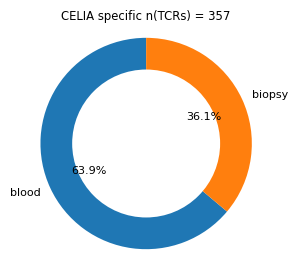

In [86]:
df = pd.read_csv('celiac_specific_CD4_clean.csv') 

fig, ax = plt.subplots(1,1,figsize=(3,3))

# count occurrences
counts = df['Tissue'].value_counts()
wedges, texts, autotexts = ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})

# create donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

ax.axis('equal')  # keep circle shape
plt.title(f"CELIA specific n(TCRs) = {len(df)}", fontsize='small')

## Repertoire

In [43]:
df = pd.read_csv('celiac_CD4_CD8_2026-02-26.csv')

df = df[["Subset","clonotype_id","TRAV","TRAJ","cdr3_TRA","TRBV","TRBJ","cdr3_TRB","Tissue","general_condition"]]

# fix columns with double values
cols = ['Tissue', 'general_condition']
df = pd.concat(
    [split_and_align(row, cols) for _, row in df.iterrows()],
    ignore_index=True
)

df['Tissue'] = np.where(df['Tissue'] == 'gut', 'biopsy', df['Tissue'])
df.to_csv('celiac_CD4_CD8_clean.csv', index=False)

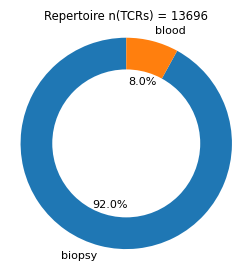

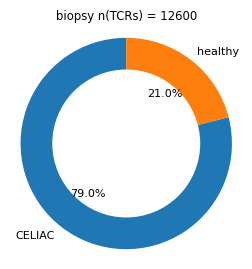

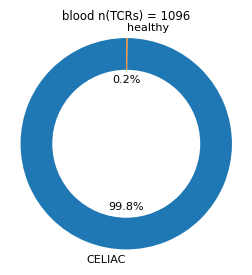

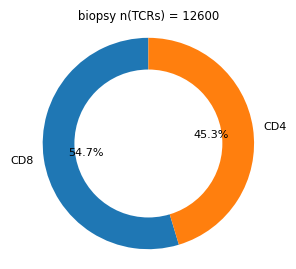

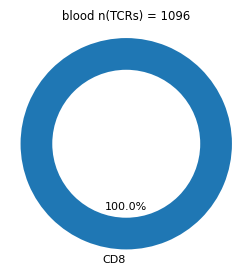

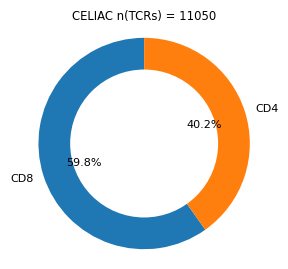

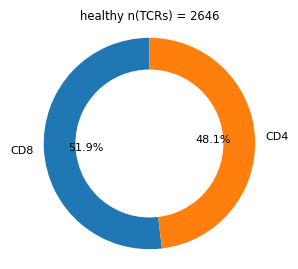

In [87]:
df = pd.read_csv('celiac_CD4_CD8_clean.csv') 

fig, ax = plt.subplots(1,1,figsize=(3,3))

# count occurrences
counts = df['Tissue'].value_counts()
wedges, texts, autotexts = ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})

# create donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

ax.axis('equal')  # keep circle shape
plt.title(f"Repertoire n(TCRs) = {len(df)}", fontsize='small')

tissues = np.unique(df['Tissue'])

for tissue in tissues:
    fig, ax = plt.subplots(1,1,figsize=(3,3))
    
    # count occurrences
    df_tissue = df[df['Tissue'] == tissue]
    counts = df_tissue['general_condition'].value_counts()
    wedges, texts, autotexts = ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})

    # create donut hole
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)

    ax.axis('equal')  # keep circle shape
    plt.title(f"{tissue} n(TCRs) = {len(df_tissue)}", fontsize='small')


# =======================================
for tissue in tissues:
    fig, ax = plt.subplots(1,1,figsize=(3,3))
    
    # count occurrences
    df_tissue = df[df['Tissue'] == tissue]
    counts = df_tissue['Subset'].value_counts()
    wedges, texts, autotexts = ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})

    # create donut hole
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)

    ax.axis('equal')  # keep circle shape
    plt.title(f"{tissue} n(TCRs) = {len(df_tissue)}", fontsize='small')

# =======================================
df = pd.read_csv('celiac_CD4_CD8_clean.csv') 
tissues = np.unique(df['general_condition'])

for tissue in tissues:
    fig, ax = plt.subplots(1,1,figsize=(3,3))
    
    # count occurrences
    df_tissue = df[df['general_condition'] == tissue]
    counts = df_tissue['Subset'].value_counts()
    wedges, texts, autotexts = ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})

    # create donut hole
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)

    ax.axis('equal')  # keep circle shape
    plt.title(f"{tissue} n(TCRs) = {len(df_tissue)}", fontsize='small')


# Motif input

# 

In [91]:
# repertoire data
df = pd.read_csv('celiac_CD4_CD8_clean.csv') 

for name, df_motif in df.groupby('general_condition'):
    df_motif.to_csv(f'celiac_CD4_CD8_{name}.csv', index=False)
    print(len(df_motif))


11050
2646


In [35]:
# celiac specific TCRs
df = pd.read_csv('celiac_specific_CD4_clean.csv') 

lst = []
for name, df_motif in df.groupby('Tissue'):
    df_motif['model'] = name
    lst.append(df_motif)

df_motif = pd.concat(lst)
df_motif.to_csv(f'celiac_specific_CD4_tissue.csv', index=False)

# split by epitope
df = df.rename(columns={'Epitope.peptide':'model'})
df = df.assign(model=df['model'].str.split('|')).explode('model')
df = df[df['model'] != 'NA']
df = df.dropna(subset=['model'])

df.to_csv('celiac_specific_CD4_epitope.csv', index=False)
print(np.unique(df['model']))
for name, group in df.groupby('model'):
    group.to_csv(f'celiac_specific_CD4_{name}.csv', index=False)

['FPQPEQPFPWQP' 'PQPELPYPQPE' 'PQQPFPQPEQPFP' 'QLQPFPQPELPY']


# TEMPO predictions after training 

In [66]:
epitopes = ['FPQPEQPFPWQP', 'PQPELPYPQPE', 'PQQPFPQPEQPFP', 'QLQPFPQPELPY']

lst = []
for epitope in epitopes:
    df = pd.read_csv(f'TEMPO_out/{epitope}/repertoire.csv')
    df = df.sort_values(by='perc_rank')
    df = df.dropna(subset=['score', 'perc_rank'])

    top = df[df['perc_rank'] < 0.05]
    top['peptide'] = epitope
    top['MHC_allele_a'] = 'HLA_DQA1_05_01'
    top['MHC_allele_b'] = 'HLA_DQB1_02_01'
    top['species'] = 'HomoSapiens'

    lst.append(top)

    bottom = df.tail(len(top))
    bottom['peptide'] = epitope
    bottom['MHC_allele_a'] = 'HLA_DQA1_05_01'
    bottom['MHC_allele_b'] = 'HLA_DQB1_02_01'
    bottom['species'] = 'HomoSapiens'
    lst.append(bottom)

df = pd.concat(lst)
df.to_csv('AF3_input_tempo.csv', index=False)

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_36356/822591459.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top['peptide'] = epitope
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_36356/822591459.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top['MHC_allele_a'] = 'HLA_DQA1_05_01'
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_36356/822591459.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

# AF3 confidence vs. TEMPO score

   clonotype_id     score  perc_rank        peptide       id  \
0      CEL13271   5.05712     0.0096   FPQPEQPFPWQP  tcr0001   
1      CEL11473   4.71105     0.0210   FPQPEQPFPWQP  tcr0002   
2       CEL7739   4.61114     0.0257   FPQPEQPFPWQP  tcr0003   
3      CEL13073   4.47300     0.0334   FPQPEQPFPWQP  tcr0004   
4      CEL11462   4.43965     0.0358   FPQPEQPFPWQP  tcr0005   
5       CEL9774   4.34862     0.0429   FPQPEQPFPWQP  tcr0006   
6      CEL11243   4.30332     0.0470   FPQPEQPFPWQP  tcr0007   
7       CEL6395  -5.81780    96.5535   FPQPEQPFPWQP  tcr0008   
8       CEL8057  13.80657     0.0001    PQPELPYPQPE  tcr0015   
9       CEL8000  14.09712     0.0001    PQPELPYPQPE  tcr0016   
10      CEL7685  10.01641     0.0003    PQPELPYPQPE  tcr0017   
11     CEL11432   7.16750     0.0082    PQPELPYPQPE  tcr0018   
12     CEL13484   6.72992     0.0130    PQPELPYPQPE  tcr0019   
13      CEL7785   6.42706     0.0183    PQPELPYPQPE  tcr0020   
14     CEL13492   5.65973     0.0413    

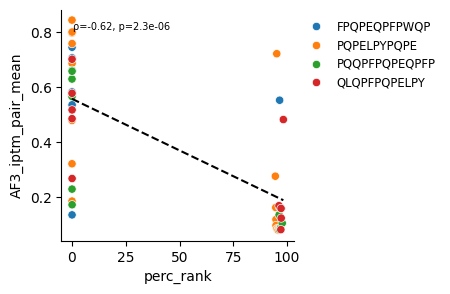

In [56]:
df_tempo = pd.read_csv('AF3_input_tempo.csv')[['clonotype_id', 'score', 'perc_rank', 'peptide']]
df_af3_in = pd.read_csv('tempo_models/AF3_tempo_input.txt', sep='\t')[['id', 'clonotype_id']]
df_af3_out = pd.read_csv('tempo_models/AF3_tempo_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
df_af3 = pd.merge(df_af3_in, df_af3_out, on='id')

df = pd.merge(df_tempo, df_af3, on='clonotype_id')
print(df)
fig, ax = plt.subplots(1,1,figsize=(3,3))
sns.scatterplot(df, x='perc_rank', y='AF3_iptm_pair_mean', hue='peptide', ax=ax)
ax.legend(bbox_to_anchor=(1,1), frameon=False, fontsize='small')
ax.set_xlabel('TEMPO score')

sns.regplot(x=df['perc_rank'], y=df['AF3_iptm_pair_mean'], ax=ax, scatter=False, color='black', line_kws={'lw':1.5, 'ls':'--'}, ci=False)
rho, pval = spearmanr(df['perc_rank'], df['AF3_iptm_pair_mean'])

# Add rho to the plot
# Format string
if pval < 0.01:
        p_str = f"{pval:.1e}"   # scientific notation
else:
        p_str = f"{pval:.2f}"   # fixed-point
        
ax.text(
0.05, 0.95, f"ρ={rho:.2f}, p={p_str}", 
transform=ax.transAxes, fontsize=7, verticalalignment='top'
)

sns.despine()

In [34]:
df_tempo = pd.read_csv('AF3_input_tempo.csv')[['clonotype_id', 'score', 'perc_rank', 'peptide']]
df_af3_in = pd.read_csv('tempo_models/AF3_tempo_input.txt', sep='\t')[['id', 'clonotype_id']]
df_af3_out = pd.read_csv('tempo_models/AF3_tempo_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
df_af3 = pd.merge(df_af3_in, df_af3_out, on='id')

df = pd.merge(df_tempo, df_af3, on='clonotype_id')
df = df[df['perc_rank'] < 0.05]

for name, group in df.groupby('peptide'):
    os.makedirs(f'tempo_models/tempo_binders/{name}', exist_ok=True)
    for i in group['id'].values:
        shutil.copy(f'tempo_models/AF3_outputs/{i}/{i}_model.cif', f'tempo_models/tempo_binders/{name}/{i}.cif')


/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_63751/3194924976.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


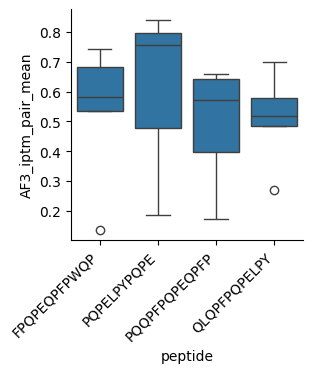

In [48]:
df_tempo = pd.read_csv('AF3_input_tempo.csv')[['clonotype_id', 'score', 'perc_rank', 'peptide', 'Subset']]
df_af3_in = pd.read_csv('tempo_models/AF3_tempo_input.txt', sep='\t')[['id', 'clonotype_id']]
df_af3_out = pd.read_csv('tempo_models/AF3_tempo_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
df_af3 = pd.merge(df_af3_in, df_af3_out, on='id')

df = pd.merge(df_tempo, df_af3, on='clonotype_id')
df = df[df['perc_rank'] < 0.05]

fig, ax = plt.subplots(1,1,figsize=(3,3))

sns.boxplot(df, x='peptide', y='AF3_iptm_pair_mean', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
sns.despine()

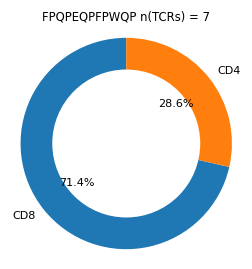

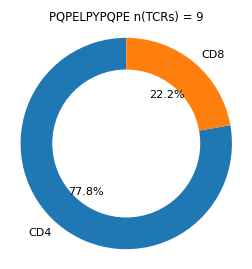

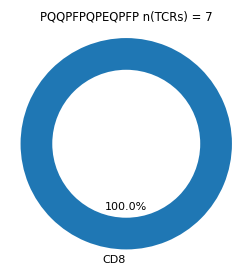

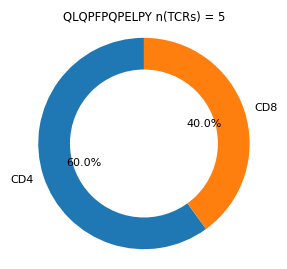

In [50]:
df_tempo = pd.read_csv('AF3_input_tempo.csv')
df_tempo = df_tempo[df_tempo['perc_rank'] < 0.05]

for name, group in df_tempo.groupby('peptide'):
    fig, ax = plt.subplots(1,1,figsize=(3,3))

    # count occurrences
    counts = group['Subset'].value_counts()
    wedges, texts, autotexts = ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})

    # create donut hole
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)

    ax.axis('equal')  # keep circle shape
    plt.title(f"{name} n(TCRs) = {len(group)}", fontsize='small')

In [64]:
df_tempo = pd.read_csv('AF3_input_tempo.csv') #[['clonotype_id', 'score', 'perc_rank', 'peptide', 'Subset']]
df_af3_in = pd.read_csv('tempo_models/AF3_tempo_input.txt', sep='\t')[['id', 'clonotype_id']]
df_af3_out = pd.read_csv('tempo_models/AF3_tempo_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
df_af3 = pd.merge(df_af3_in, df_af3_out, on='id')

df = pd.merge(df_tempo, df_af3, on='clonotype_id')
df = df.sort_values(by='perc_rank')
df = df[df['perc_rank'] < 0.05]
df.to_csv('celiac_TEMPO_hits.csv', index=False)
df

,Subset,clonotype_id,TRAV,TRAJ,cdr3_TRA,TRBV,TRBJ,cdr3_TRB,Tissue,general_condition,score,perc_rank,Problem,peptide,MHC_allele_a,MHC_allele_b,species,id,AF3_iptm_pair_mean
9,CD4,CEL8000,TRAV26-1,TRAJ42,CIVYGGSQGNLIF,TRBV7-3,TRBJ2-3,CASSFRSTDTQYF,biopsy,CELIAC,14.09712,0.0001,NaN,PQPELPYPQPE,HLA_DQA1_05_01,HLA_DQB1_02_01,HomoSapiens,tcr0016,0.795000
8,CD4,CEL8057,TRAV26-1,TRAJ48,CIVLNEKLTF,TRBV7-2,TRBJ2-3,CASSIRATDTQYF,biopsy,CELIAC,13.80657,0.0001,NaN,PQPELPYPQPE,HLA_DQA1_05_01,HLA_DQB1_02_01,HomoSapiens,tcr0015,0.796667
10,CD4,CEL7685,TRAV25,TRAJ47,CAGPYGNKLVF,TRBV7-2,TRBJ2-3,CASSFRSTDTQYF,biopsy,CELIAC,10.01641,0.0003,NaN,PQPELPYPQPE,HLA_DQA1_05_01,HLA_DQB1_02_01,HomoSapiens,tcr0017,0.841667
25,CD8,CEL11261,TRAV4,TRAJ12,CLVEGDSSYKLIF,TRBV5-1,TRBJ2-1,CASSLAREGGAEQFF,biopsy,healthy,6.08863,0.0016,NaN,PQQPFPQPEQPFP,HLA_DQA1_05_01,HLA_DQB1_02_01,HomoSapiens,tcr0033,0.570000
26,CD8,CEL11417,TRAV4,TRAJ4,CLVVTQGGYNKLIF,TRBV5-1,TRBJ2-5,CASYGGAEETQYF,biopsy,CELIAC,5.28892,0.0077,NaN,PQQPFPQPEQPFP,HLA_DQA1_05_01,HLA_DQB1_02_01,HomoSapiens,tcr0034,0.628333
11,CD8,CEL11432,TRAV4,TRAJ43,CLVGENDMRF,TRBV7-2,TRBJ2-3,CASSLVDPTDTQYF,blood,CELIAC,7.16750,0.0082,NaN,PQPELPYPQPE,HLA_DQA1_05_01,HLA_DQB1_02_01,HomoSapiens,tcr0018,0.321667
0,CD4,CEL13271,TRAV8-6,TRAJ37,CAVSGGNTGKLIF,TRBV15,TRBJ1-2,CATSRRAQGGYTF,biopsy,CELIAC,5.05712,0.0096,NaN,FPQPEQPFPWQP,HLA_DQA1_05_01,HLA_DQB1_02_01,HomoSapiens,tcr0001,0.533333
12,CD8,CEL13484,TRAV9-2,TRAJ20,CAAYNDYKLSF,TRBV2,TRBJ2-3,CASEGLAGGWGTDTQYF,biopsy,CELIAC,6.72992,0.0130,NaN,PQPELPYPQPE,HLA_DQA1_05_01,HLA_DQB1_02_01,HomoSapiens,tcr0019,0.478333
27,CD8,CEL11258,TRAV4,TRAJ12,CLVEGDSSYKLIF,TRBV20-1,TRBJ2-7,CSARGLAEPYEQYF,biopsy,healthy,4.99018,0.0148,NaN,PQQPFPQPEQPFP,HLA_DQA1_05_01,HLA_DQB1_02_01,HomoSapiens,tcr0035,0.565000
38,CD8,CEL11284,TRAV4,TRAJ18,CLVGDPADRGSTLGRLYF,TRBV4-3,TRBJ2-1,CASSQGAGEAYNEQFF,biopsy,CELIAC,5.79791,0.0173,NaN,QLQPFPQPELPY,HLA_DQA1_05_01,HLA_DQB1_02_01,HomoSapiens,tcr0047,0.576667


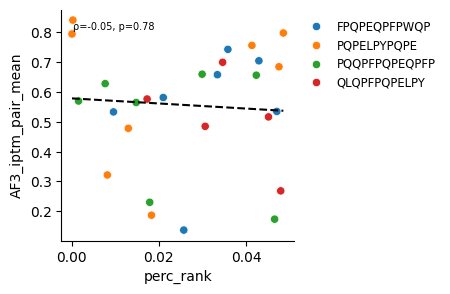

In [63]:
df_tempo = pd.read_csv('AF3_input_tempo.csv')[['clonotype_id', 'score', 'perc_rank', 'peptide']]
df_af3_in = pd.read_csv('tempo_models/AF3_tempo_input.txt', sep='\t')[['id', 'clonotype_id']]
df_af3_out = pd.read_csv('tempo_models/AF3_tempo_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
df_af3 = pd.merge(df_af3_in, df_af3_out, on='id')

df = pd.merge(df_tempo, df_af3, on='clonotype_id')
df = df[df['perc_rank'] < 0.05]
fig, ax = plt.subplots(1,1,figsize=(3,3))
sns.scatterplot(df, x='perc_rank', y='AF3_iptm_pair_mean', hue='peptide', ax=ax)
ax.legend(bbox_to_anchor=(1,1), frameon=False, fontsize='small')
ax.set_xlabel('TEMPO score')

sns.regplot(x=df['perc_rank'], y=df['AF3_iptm_pair_mean'], ax=ax, scatter=False, color='black', line_kws={'lw':1.5, 'ls':'--'}, ci=False)
rho, pval = spearmanr(df['perc_rank'], df['AF3_iptm_pair_mean'])

# Add rho to the plot
# Format string
if pval < 0.01:
        p_str = f"{pval:.1e}"   # scientific notation
else:
        p_str = f"{pval:.2f}"   # fixed-point
        
ax.text(
0.05, 0.95, f"ρ={rho:.2f}, p={p_str}", 
transform=ax.transAxes, fontsize=7, verticalalignment='top'
)

sns.despine()